In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("data/wine_quality.csv", sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(240)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [11]:
X = df.drop(columns='quality')
y = df['quality']

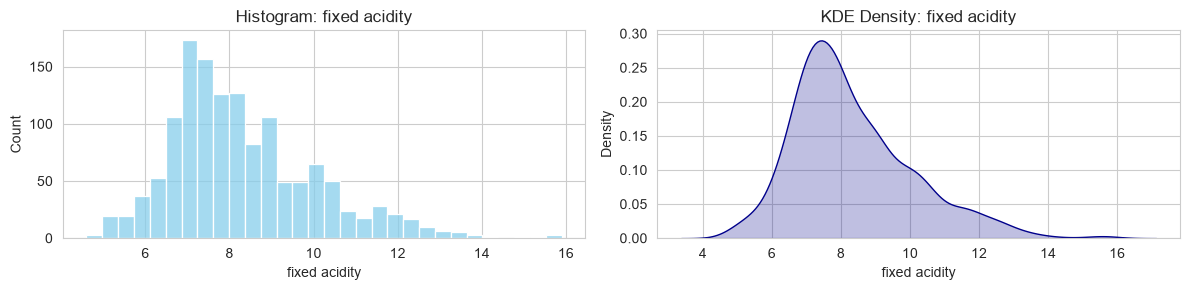

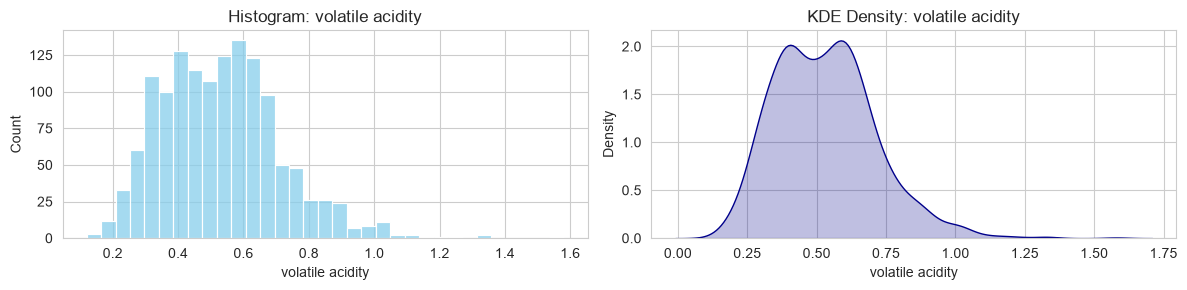

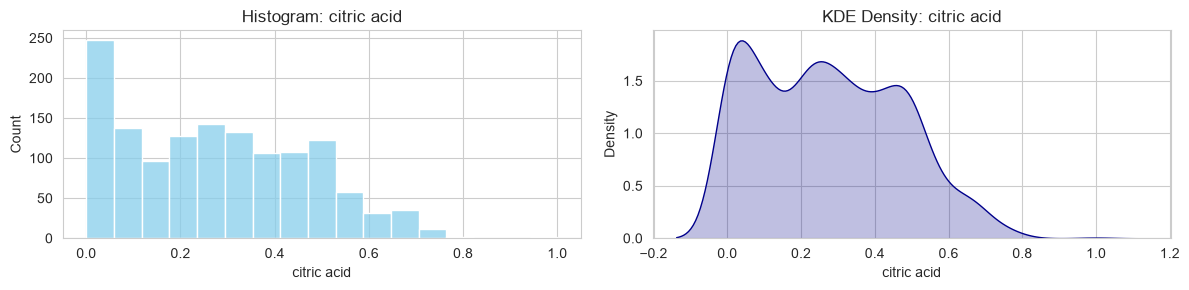

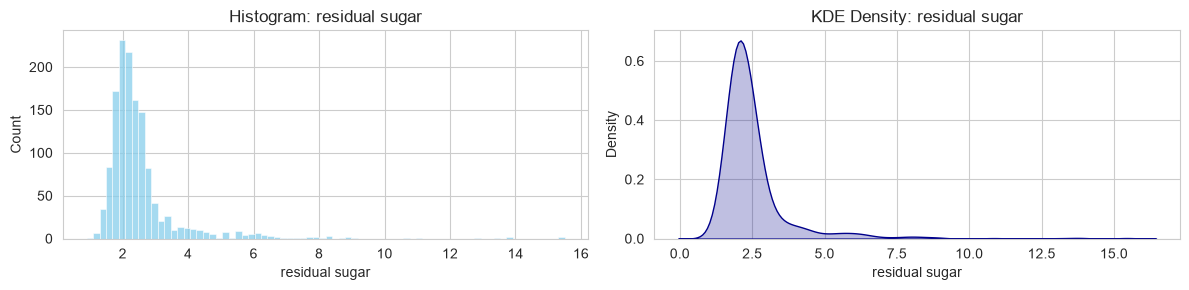

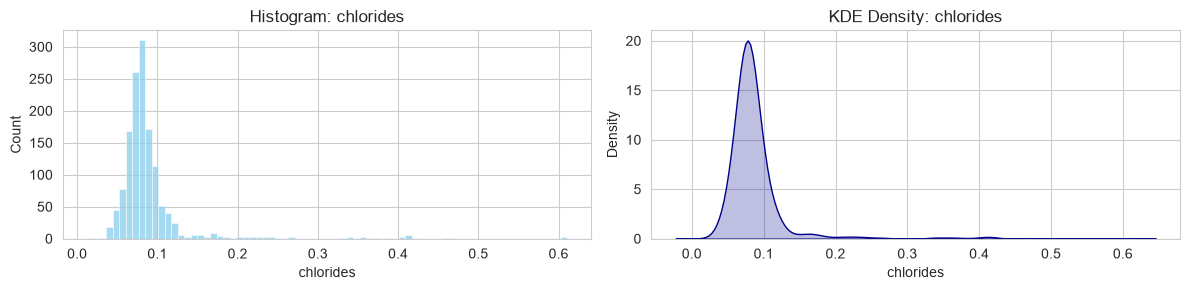

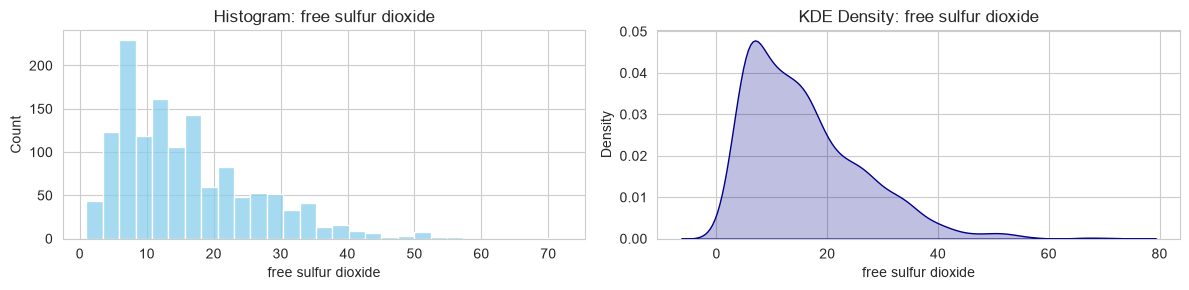

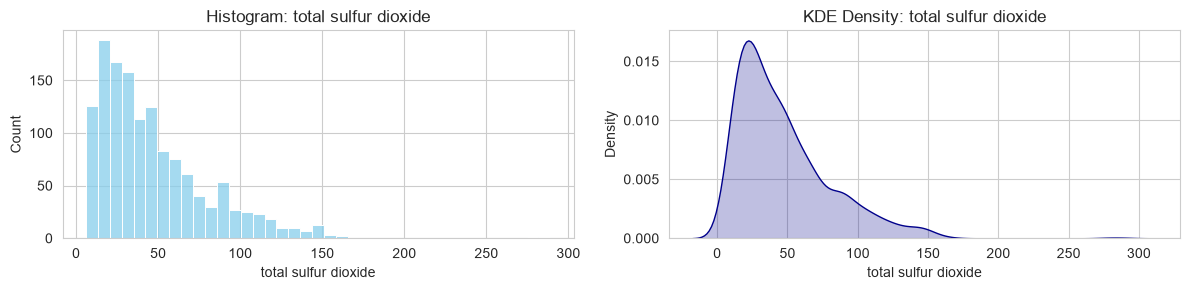

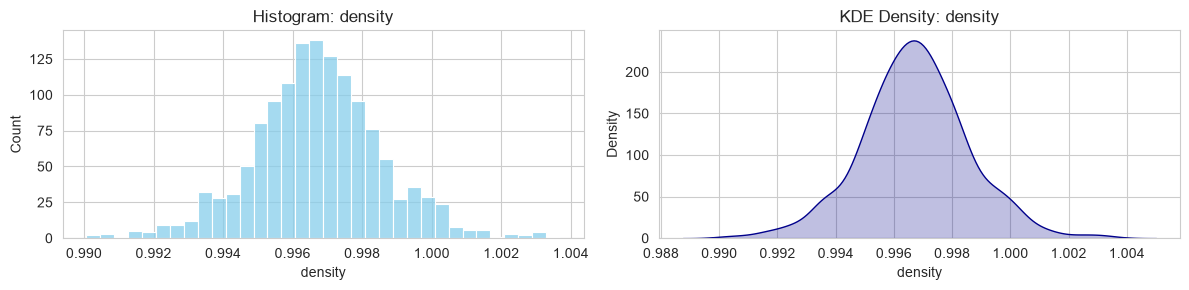

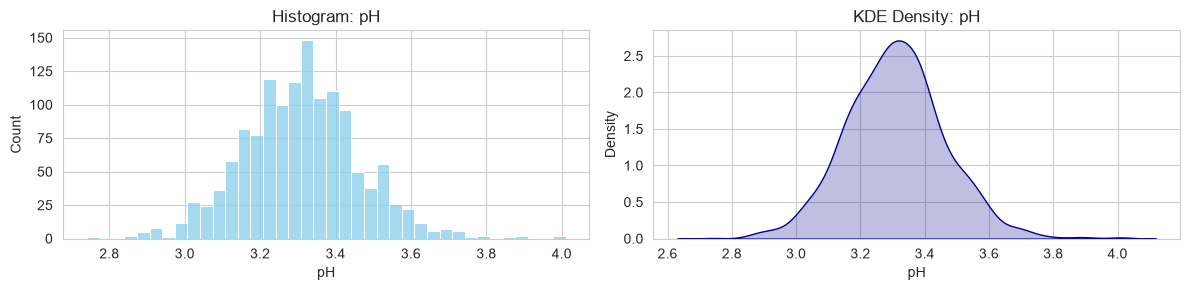

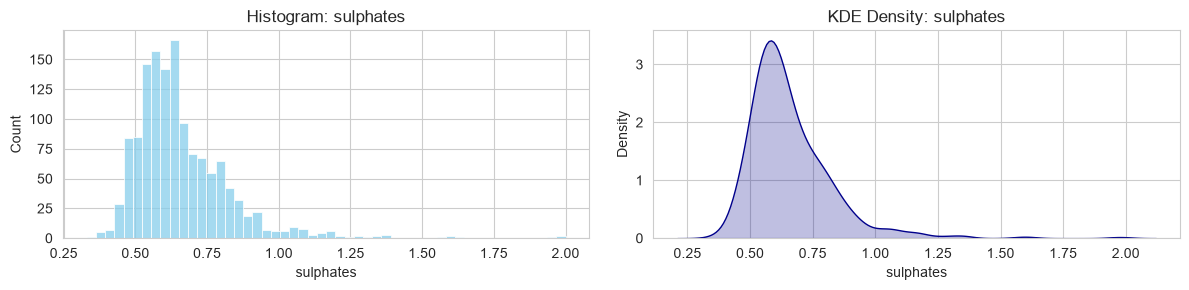

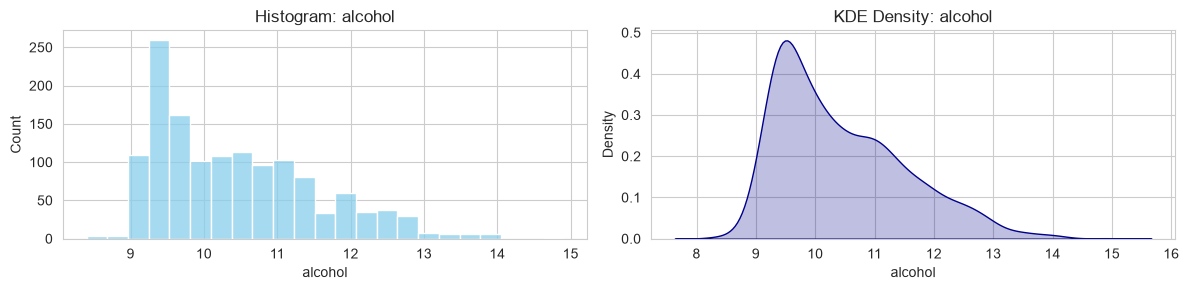

In [13]:
for col in X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    sns.histplot(X[col], ax=axes[0], color='skyblue')
    axes[0].set_title(f"Histogram: {col}")
    
    sns.kdeplot(X[col], ax=axes[1], color='darkblue', fill=True)
    axes[1].set_title(f"KDE Density: {col}")
    
    plt.tight_layout()
    plt.show()


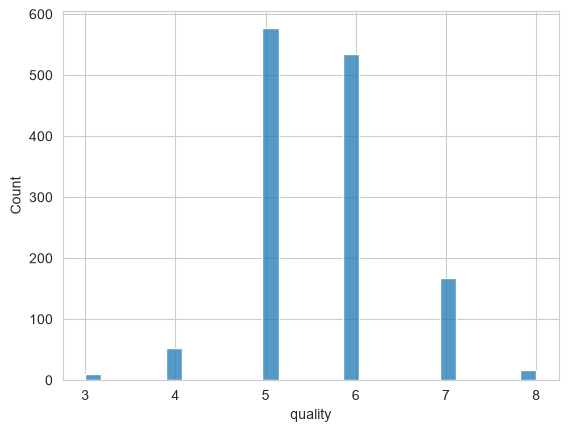

In [14]:
sns.histplot(y)
plt.show()

<Figure size 1200x1200 with 0 Axes>

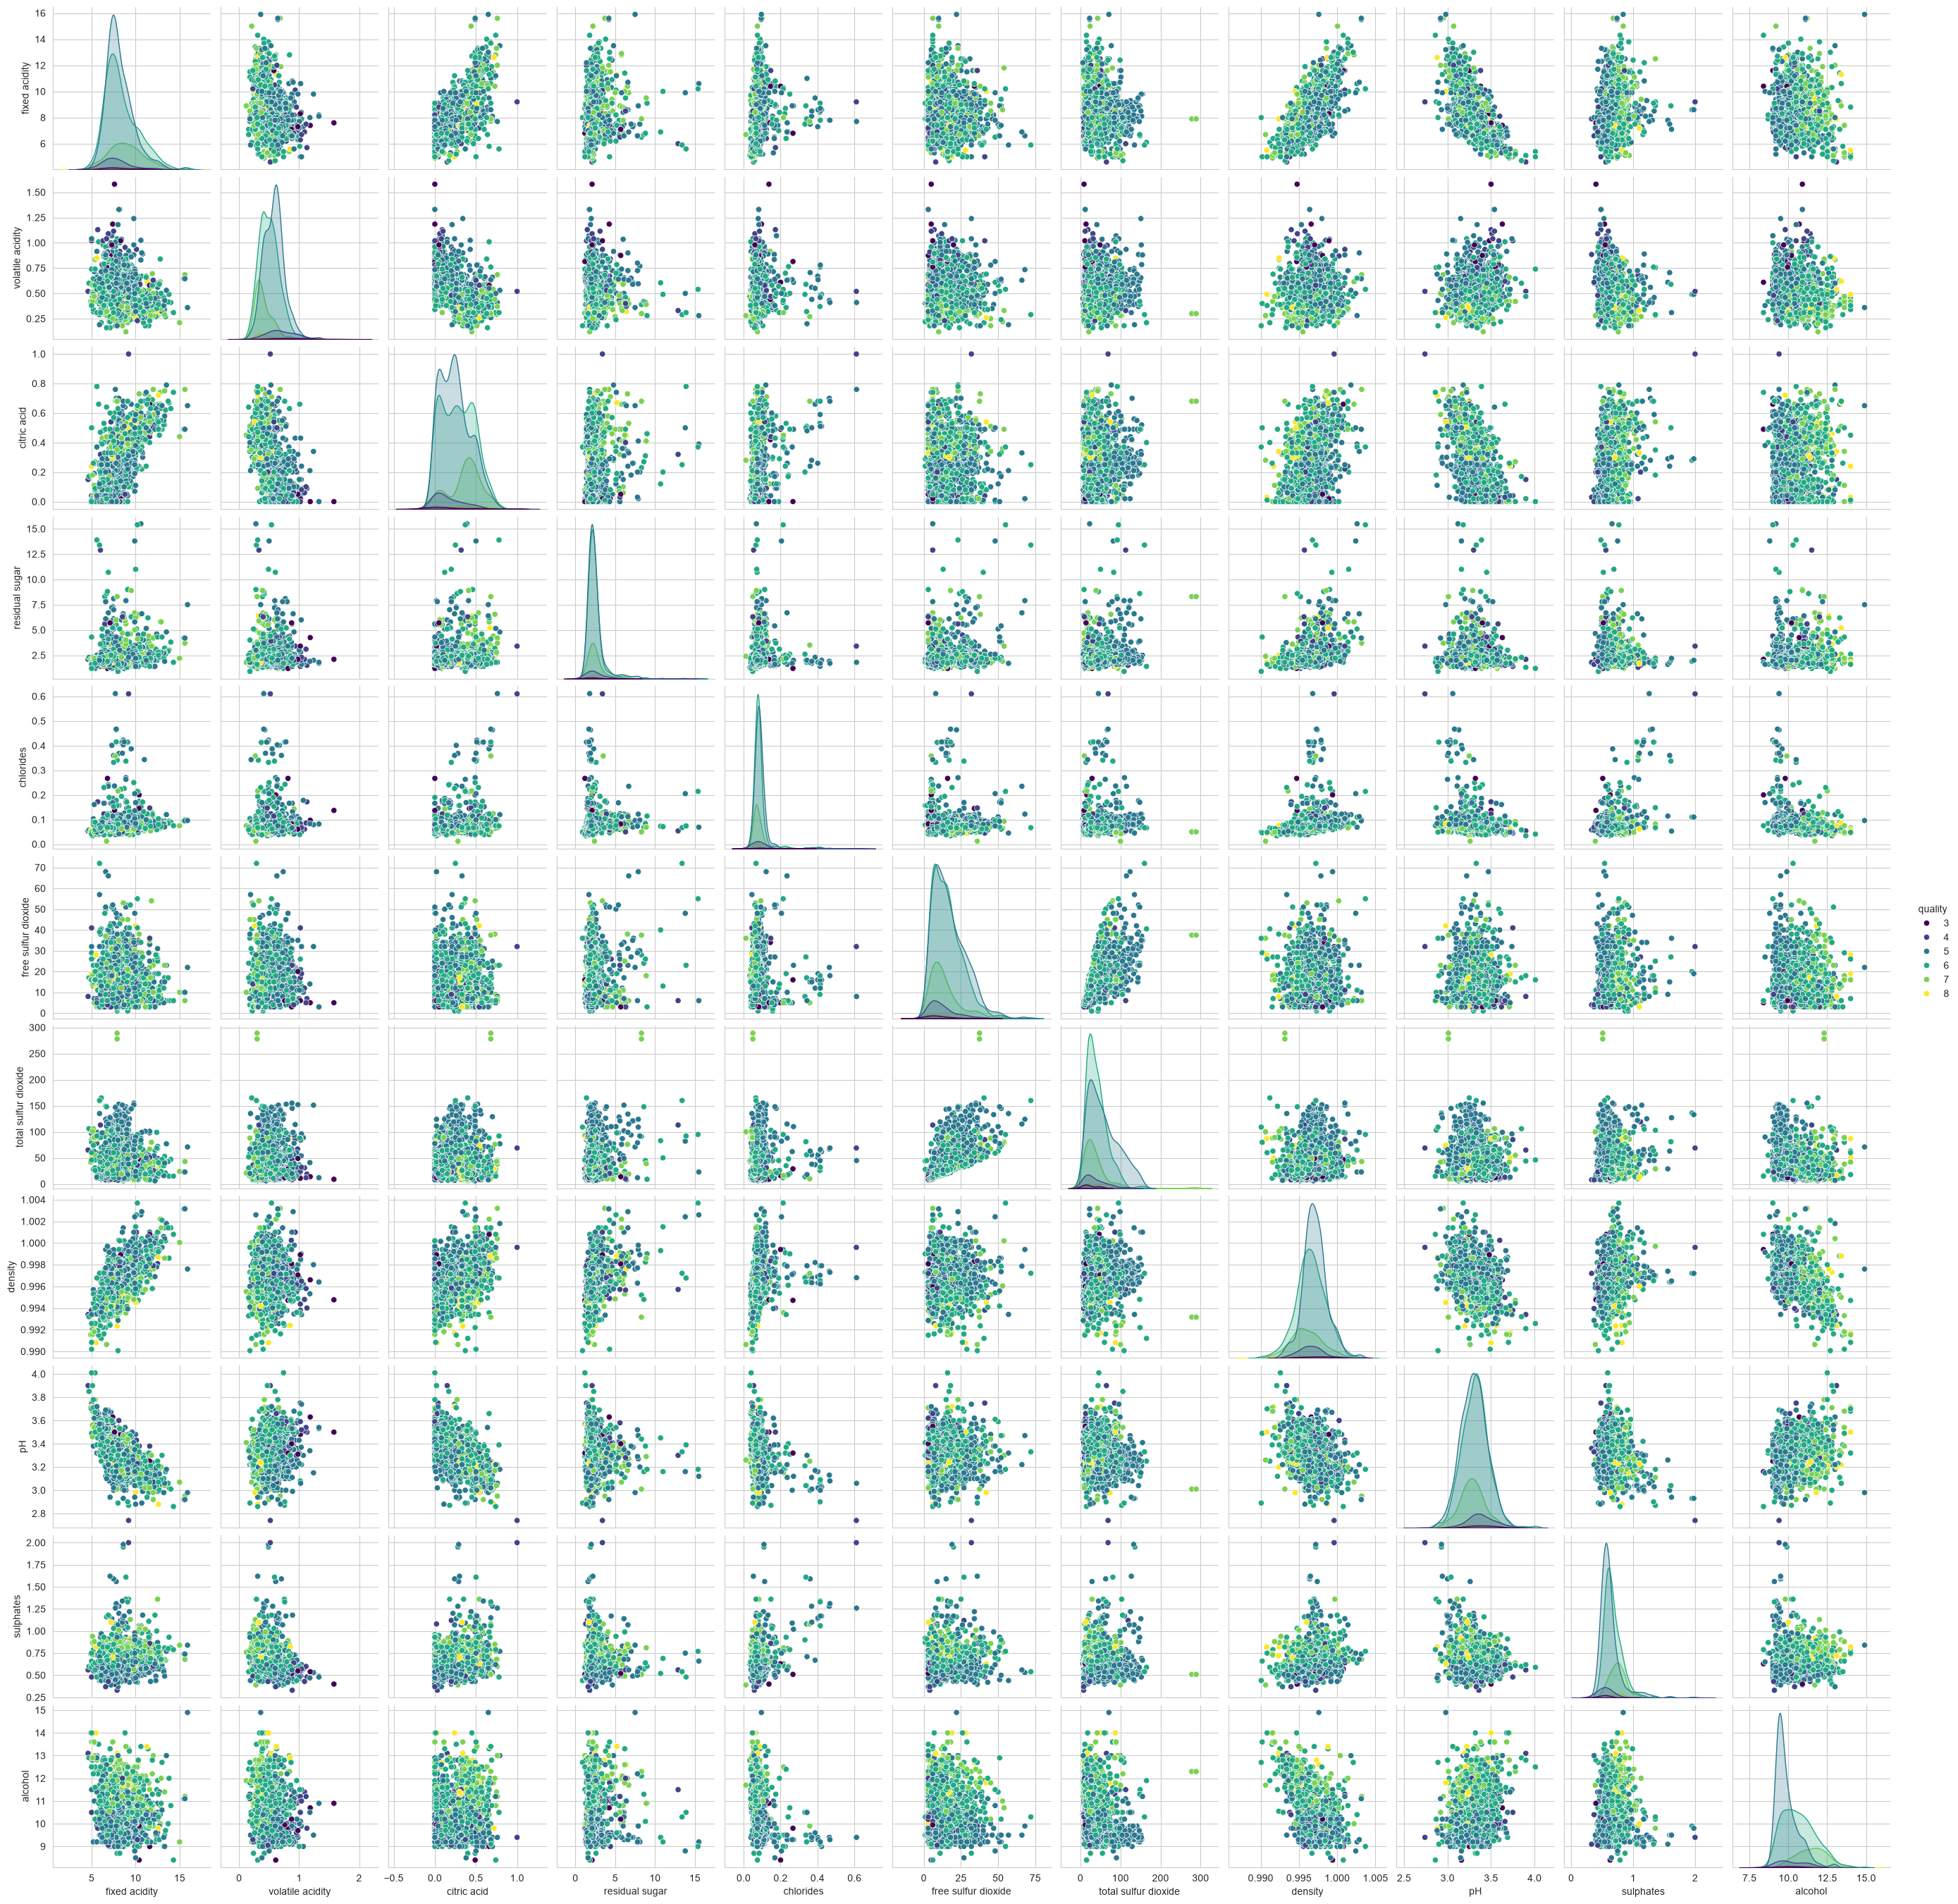

In [16]:
plt.figure(figsize=(12, 12))
sns.pairplot(df, hue='quality', palette='viridis')
plt.show()

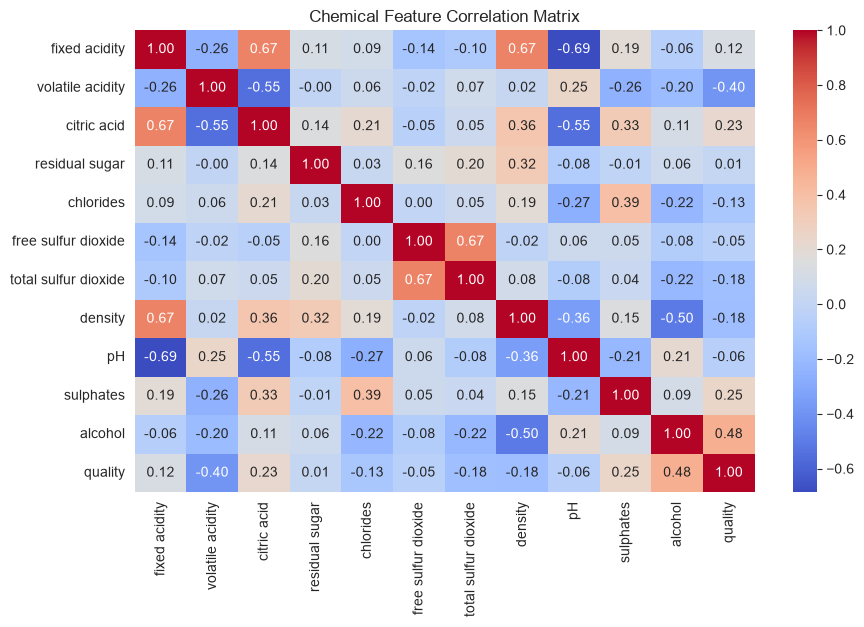

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Chemical Feature Correlation Matrix")
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

models = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', allow_writing_files=False, verbose=0, random_state=42),
    "XGBoost": XGBClassifier(tree_method='hist', eval_metric='mlogloss', random_state=42)
}

y_encoded = y - 3

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running Clean 5-Fold Multi-Class CV Benchmark...\n")

for name, model in models.items():
    target = y_encoded if "XGBoost" in name else y
    
    scores = cross_validate(
        model, X, target, cv=cv,
        scoring=['f1_macro', 'f1_weighted', 'accuracy'],
        n_jobs=-1
    )
    
    results.append({
        'Model': name,
        'Macro F1 (Unweighted)': scores['test_f1_macro'].mean(),
        'Weighted F1': scores['test_f1_weighted'].mean(),
        'Accuracy': scores['test_accuracy'].mean()
    })
    print(f"{name:<22} | Macro F1: {scores['test_f1_macro'].mean():.4f} | Accuracy: {scores['test_accuracy'].mean():.4f}")

df_results = pd.DataFrame(results).sort_values(by='Macro F1 (Unweighted)', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("DAY 6 MULTI-CLASS WINE QUALITY LEADERBOARD")
print("="*70)
print(df_results.to_string(index=False))


Running Clean 5-Fold Multi-Class CV Benchmark...

Logistic Regression    | Macro F1: 0.2873 | Accuracy: 0.4246
Decision Tree          | Macro F1: 0.2592 | Accuracy: 0.4305
Random Forest          | Macro F1: 0.3093 | Accuracy: 0.5585
HistGradientBoosting   | Macro F1: 0.2864 | Accuracy: 0.5644
LightGBM               | Macro F1: 0.2882 | Accuracy: 0.5718
CatBoost               | Macro F1: 0.2973 | Accuracy: 0.5688
XGBoost                | Macro F1: 0.2788 | Accuracy: 0.5813

DAY 6 MULTI-CLASS WINE QUALITY LEADERBOARD
               Model  Macro F1 (Unweighted)  Weighted F1  Accuracy
       Random Forest               0.309325     0.554065  0.558503
            CatBoost               0.297252     0.562197  0.568806
            LightGBM               0.288182     0.558687  0.571766
 Logistic Regression               0.287313     0.463519  0.424585
HistGradientBoosting               0.286391     0.552660  0.564402
             XGBoost               0.278794     0.562941  0.581327
       Dec

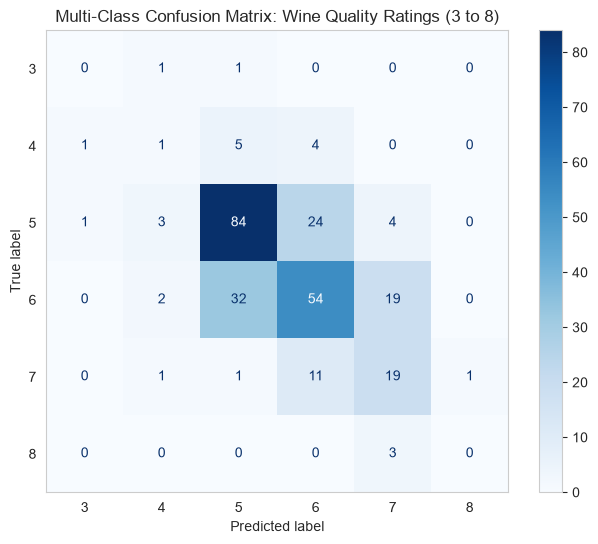

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_champion = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf_champion.fit(X_tr, y_tr)
y_pred_rf = rf_champion.predict(X_te)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_te, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[3, 4, 5, 6, 7, 8])
disp.plot(cmap='Blues', ax=ax)
plt.title("Multi-Class Confusion Matrix: Wine Quality Ratings (3 to 8)")
plt.grid(False)
plt.show()


In [21]:
df['quality_tier'] = df['quality'].map({3: 0, 4: 0, 5: 1, 6: 1, 7: 2, 8: 2})

X_tier = df.drop(columns=['quality', 'quality_tier'])
y_tier = df['quality_tier']

rf_tier = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
scores_tier = cross_validate(rf_tier, X_tier, y_tier, cv=cv, scoring=['f1_macro', 'accuracy'])

print(f"3-Tier Business Classification Accuracy: {scores_tier['test_accuracy'].mean():.4f} ({scores_tier['test_accuracy'].mean()*100:.1f}%)")
print(f"3-Tier Business Classification Macro F1: {scores_tier['test_f1_macro'].mean():.4f}")


3-Tier Business Classification Accuracy: 0.8050 (80.5%)
3-Tier Business Classification Macro F1: 0.5544


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf_reg.fit(X_tr, y_tr)

y_pred_cont = rf_reg.predict(X_te)
y_pred_ordinal = np.clip(np.round(y_pred_cont), 3, 8).astype(int)

from sklearn.metrics import accuracy_score, f1_score
print(f"Ordinal Regression Exact 6-Class Accuracy: {accuracy_score(y_te, y_pred_ordinal):.4f} ({accuracy_score(y_te, y_pred_ordinal)*100:.1f}%)")
print(f"Ordinal Regression Macro F1:              {f1_score(y_te, y_pred_ordinal, average='macro'):.4f}")

Ordinal Regression Exact 6-Class Accuracy: 0.5993 (59.9%)
Ordinal Regression Macro F1:              0.3097


In [23]:
df['acid_ratio'] = df['volatile acidity'] / (df['fixed acidity'] + 1e-5)
df['bound_so2'] = df['total sulfur dioxide'] - df['free sulfur dioxide']
df['free_so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']
df['alcohol_to_density'] = df['alcohol'] / df['density']

In [24]:
X_feat = df.drop(columns=['quality'])
y_feat = df['quality']

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_feat, y_feat, test_size=0.2, random_state=42, stratify=y_feat)

rf_reg = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_f, y_tr_f)

y_pred_cont = rf_reg.predict(X_te_f)
y_pred_ordinal = np.clip(np.round(y_pred_cont), 3, 8).astype(int)

print(f"Engineered Ordinal Regression Accuracy: {accuracy_score(y_te_f, y_pred_ordinal):.4f} ({accuracy_score(y_te_f, y_pred_ordinal)*100:.1f}%)")
print(f"Engineered Ordinal Regression Macro F1: {f1_score(y_te_f, y_pred_ordinal, average='macro'):.4f}")

Engineered Ordinal Regression Accuracy: 0.7794 (77.9%)
Engineered Ordinal Regression Macro F1: 0.5633
